# Обучение модели прогноза цен (LightGBM)

**Модель:** LightGBM Regressor  
**Целевая переменная:** `price_rub_per_ton` — цена сельхозпродукции, руб./тонна  
**Охват:** 73 региона России, 16 культур, ежемесячные данные  
**Валидация:** Rolling Time CV — обучение на годах до T, тест на году T (последние 5 лет)

---

## Структура ноутбука
1. Загрузка и первичный анализ данных
2. Описание признаков
3. Подготовка данных и кодирование
4. Rolling Time кросс-валидация
5. Финальная модель на всех данных
6. Feature importance
7. Сохранение артефактов
8. Пример инференса

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

# Ноутбук лежит в agro-ml-service/notebooks/
# DATA_DIR = agro-ml-service/data/
NOTEBOOK_DIR = Path('.').resolve()
SERVICE_DIR = NOTEBOOK_DIR.parent
DATA_DIR = SERVICE_DIR / 'data'
MODELS_DIR = SERVICE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

PRICE_CSV = DATA_DIR / 'price_master.csv'

print('Библиотеки загружены')
print(f'LightGBM версия: {lgb.__version__}')
print(f'Файл данных: {PRICE_CSV.resolve()}')
print(f'Папка моделей: {MODELS_DIR.resolve()}')

Библиотеки загружены
LightGBM версия: 4.6.0
Файл данных: C:\Users\nikit\IdeaProjects\AgroPlanPro\agro-ml-service\data\price_master.csv
Папка моделей: C:\Users\nikit\IdeaProjects\AgroPlanPro\agro-ml-service\models


## 1. Загрузка и первичный анализ данных

`price_master.csv` — ежемесячные цены по регионам и культурам.
Каждая строка: (регион, культура, год, месяц) + лаговые и скользящие признаки.

In [2]:
pdf = pd.read_csv(PRICE_CSV)

print(f'Всего строк  : {len(pdf):,}')
print(f'Культур      : {pdf["crop"].nunique()} — {sorted(pdf["crop"].unique())}')
print(f'Регионов     : {pdf["region"].nunique()}')
print(f'Годы         : {pdf["year"].min()} – {pdf["year"].max()}')
print(f'Цена, руб/т  : min={pdf["price_rub_per_ton"].min():.0f}, '
      f'max={pdf["price_rub_per_ton"].max():.0f}, '
      f'mean={pdf["price_rub_per_ton"].mean():.0f}')

pdf.head()

Всего строк  : 76,160
Культур      : 16 — ['barley', 'buckwheat', 'corn', 'durum_wheat', 'millet', 'oat', 'peas', 'rapeseed', 'rye', 'sunflower', 'wheat', 'wheat_grade_1', 'wheat_grade_2', 'wheat_grade_3', 'wheat_grade_4', 'wheat_grade_5']
Регионов     : 73
Годы         : 2010 – 2025
Цена, руб/т  : min=173, max=98031, mean=9443


,region,crop,year,month,month_num,price_rub_per_ton,price_lag1,price_lag12,price_lag24,price_ma3,price_ma12,price_mom,price_yoy,price_vol_3m,price_vol_12m,price_cv,price_direction
0,Алтайский край,barley,2010,январь,1,3785.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STABLE
1,Алтайский край,barley,2010,февраль,2,3785.19,3785.19,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,STABLE
2,Алтайский край,barley,2010,март,3,3469.27,3785.19,NaN,NaN,3785.190000,NaN,-0.083462,NaN,0.000000,NaN,NaN,STABLE
3,Алтайский край,barley,2010,апрель,4,3208.42,3469.27,NaN,NaN,3679.883333,NaN,-0.075189,NaN,182.396497,NaN,NaN,STABLE
4,Алтайский край,barley,2010,май,5,3045.62,3208.42,NaN,NaN,3487.626667,NaN,-0.050741,NaN,288.822841,NaN,NaN,STABLE


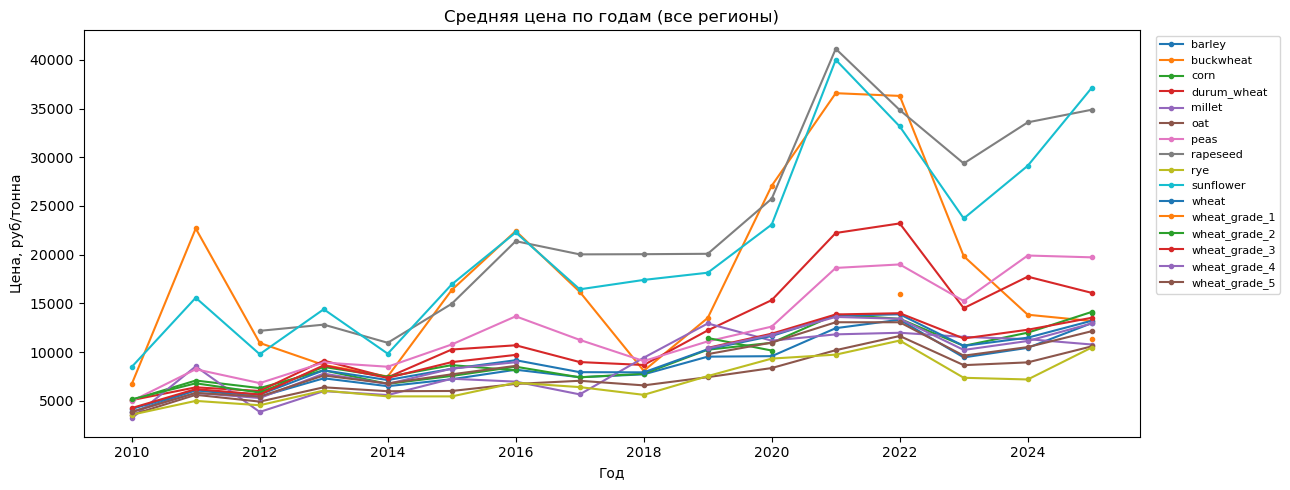

In [3]:
# Динамика средней цены по культурам по годам
price_by_year = pdf.groupby(['year', 'crop'])['price_rub_per_ton'].mean().unstack('crop')

fig, ax = plt.subplots(figsize=(13, 5))
for crop in price_by_year.columns:
    ax.plot(price_by_year.index, price_by_year[crop], marker='o', markersize=3, label=crop)
ax.set_title('Средняя цена по годам (все регионы)')
ax.set_xlabel('Год')
ax.set_ylabel('Цена, руб/тонна')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 2. Описание признаков

Ценовая модель — авторегрессионная: ключевые признаки это прошлые значения цены.
Погодные данные не используются напрямую — они уже частично отражены в лагах.

| Признак | Описание |
|---------|----------|
| `year`, `month_num` | Год и номер месяца (1–12) |
| `price_lag1` | Цена 1 месяц назад |
| `price_lag12` | Цена 12 месяцев назад (год назад) |
| `price_lag24` | Цена 24 месяца назад |
| `price_ma3` | Скользящая средняя за 3 месяца |
| `price_ma12` | Скользящая средняя за 12 месяцев |
| `price_mom` | Month-over-month изменение, % |
| `price_yoy` | Year-over-year изменение, % |
| `price_vol_3m` | Волатильность за 3 месяца |
| `price_vol_12m` | Волатильность за 12 месяцев |
| `price_cv` | Коэффициент вариации |
| `crop` | Культура (label-encoded) |
| `region` | Регион (label-encoded) |

## 3. Подготовка данных

In [4]:
PRICE_NUMERIC = [
    'year', 'month_num',
    'price_lag1', 'price_lag12', 'price_lag24',
    'price_ma3', 'price_ma12',
    'price_yoy', 'price_mom',
    'price_vol_3m', 'price_vol_12m', 'price_cv',
]
PRICE_CAT    = ['crop', 'region']
PRICE_TARGET = 'price_rub_per_ton'

p_num_cols  = [c for c in PRICE_NUMERIC if c in pdf.columns]
p_all_feats = PRICE_CAT + p_num_cols

# Убираем строки без целевой переменной
pdf_model = pdf.dropna(subset=[PRICE_TARGET]).copy()

# LightGBM нативно обрабатывает NaN в числовых признаках — fillna не нужен
print(f'Строк после фильтрации: {len(pdf_model):,}')
print(f'Признаков: {len(p_all_feats)} ({len(PRICE_CAT)} категориальных + {len(p_num_cols)} числовых)')

Строк после фильтрации: 76,160
Признаков: 14 (2 категориальных + 12 числовых)


In [5]:
# Кодирование категориальных признаков
p_encoders = {}
for col in PRICE_CAT:
    le = LabelEncoder()
    le.fit(pdf_model[col].astype(str))
    p_encoders[col] = le

pdf_enc = pdf_model.copy()
for col, le in p_encoders.items():
    pdf_enc[col] = le.transform(pdf_enc[col].astype(str))

print('Энкодеры:')
for col, le in p_encoders.items():
    print(f'  {col}: {le.classes_[:5].tolist()} ... ({len(le.classes_)} значений)')

Энкодеры:
  crop: ['barley', 'buckwheat', 'corn', 'durum_wheat', 'millet'] ... (16 значений)
  region: ['Алтайский край', 'Амурская область', 'Астраханская область', 'Белгородская область', 'Брянская область'] ... (73 значений)


## 4. Rolling Time кросс-валидация

**Rolling CV** — стандартная временная валидация для временных рядов:
- Тестируем на последних 5 годах (по одному за итерацию)
- Обучаем только на данных до тестового года
- Исключаем утечку будущего в обучение
- Цена НЕ логарифмируется (в отличие от урожайности) — распределение более симметрично

In [6]:
LGBM_PARAMS = dict(
    objective='regression',
    metric='rmse',
    num_leaves=63,
    learning_rate=0.05,
    n_estimators=800,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100)

def train_lgbm(X_train, y_train, X_val, y_val, params):
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0),
        ],
    )
    return model

p_years    = sorted(pdf_enc['year'].unique())
test_years = p_years[-5:]   # последние 5 лет
p_cv_rows  = []

print(f'{'Год':>6} | {'R2':>7} | {'RMSE':>9} | {'MAE':>9} | {'MAPE%':>6} | {'n':>6}')
print('-' * 58)

for test_year in test_years:
    tr = pdf_enc[pdf_enc['year'] <  test_year].copy()
    te = pdf_enc[pdf_enc['year'] == test_year].copy()

    if len(te) < 50 or len(tr) < 500:
        continue

    eval_year = sorted(tr['year'].unique())[-1]
    tr_fit = tr[tr['year'] != eval_year]
    tr_val = tr[tr['year'] == eval_year]

    model = train_lgbm(
        tr_fit[p_all_feats], tr_fit[PRICE_TARGET].values,
        tr_val[p_all_feats], tr_val[PRICE_TARGET].values,
        LGBM_PARAMS,
    )
    pred = model.predict(te[p_all_feats])
    y_te = te[PRICE_TARGET].values

    r2_val = r2_score(y_te, pred)
    p_cv_rows.append({
        'year': test_year,
        'r2':   r2_val,
        'rmse': rmse(y_te, pred),
        'mae':  mean_absolute_error(y_te, pred),
        'mape': mape(y_te, pred),
        'n':    len(te),
    })
    print(f'{test_year:>6} | {r2_val:>7.4f} | {rmse(y_te, pred):>9.0f} | '
          f'{mean_absolute_error(y_te, pred):>9.0f} | {mape(y_te, pred):>6.1f} | {len(te):>6}')

p_cv_df = pd.DataFrame(p_cv_rows)
print('-' * 58)
print(f'{'MEAN':>6} | {p_cv_df["r2"].mean():>7.4f} | {p_cv_df["rmse"].mean():>9.0f} | '
      f'{p_cv_df["mae"].mean():>9.0f} | {p_cv_df["mape"].mean():>6.1f}')
print(f'\nCV R2 = {p_cv_df["r2"].mean():.4f}')

   Год |      R2 |      RMSE |       MAE |  MAPE% |      n
----------------------------------------------------------
  2021 |  0.8633 |      2858 |       868 |    2.9 |   3402
  2022 |  0.8907 |      2431 |       747 |    2.7 |   3317
  2023 |  0.9730 |       873 |       318 |    2.2 |   3478
  2024 |  0.9923 |       572 |       218 |    1.5 |   3457
  2025 |  0.9801 |      1105 |       308 |    1.4 |   3283
----------------------------------------------------------
  MEAN |  0.9399 |      1568 |       492 |    2.1

CV R2 = 0.9399


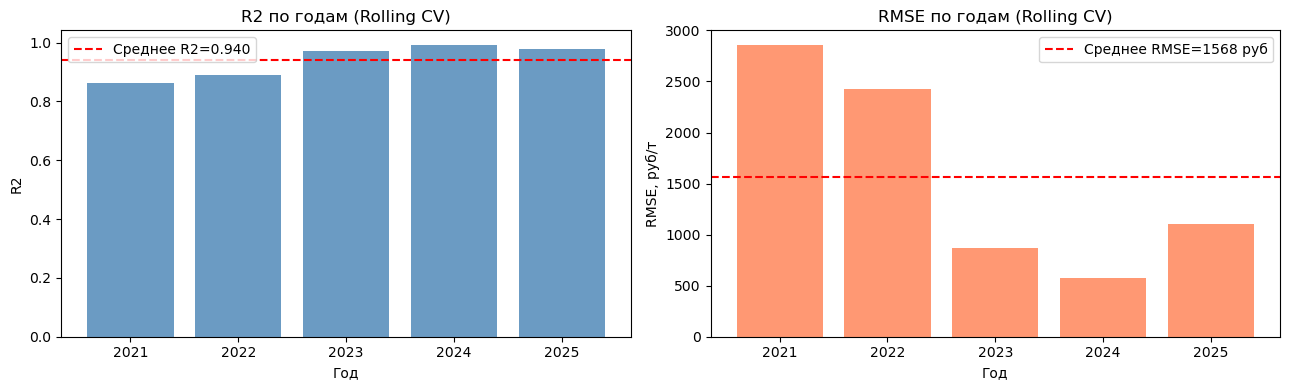

In [7]:
# Визуализация CV-метрик
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(p_cv_df['year'], p_cv_df['r2'], color='steelblue', alpha=0.8)
axes[0].axhline(p_cv_df['r2'].mean(), color='red', linestyle='--',
                label=f'Среднее R2={p_cv_df["r2"].mean():.3f}')
axes[0].set_title('R2 по годам (Rolling CV)')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('R2')
axes[0].legend()

axes[1].bar(p_cv_df['year'], p_cv_df['rmse'], color='coral', alpha=0.8)
axes[1].axhline(p_cv_df['rmse'].mean(), color='red', linestyle='--',
                label=f'Среднее RMSE={p_cv_df["rmse"].mean():.0f} руб')
axes[1].set_title('RMSE по годам (Rolling CV)')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('RMSE, руб/т')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Финальная модель на всех данных

In [8]:
last_p_year = sorted(pdf_enc['year'].unique())[-1]
tr_p_all    = pdf_enc[pdf_enc['year'] != last_p_year]
val_p_all   = pdf_enc[pdf_enc['year'] == last_p_year]

final_price = train_lgbm(
    tr_p_all[p_all_feats],  tr_p_all[PRICE_TARGET].values,
    val_p_all[p_all_feats], val_p_all[PRICE_TARGET].values,
    LGBM_PARAMS,
)

print(f'Финальная модель обучена')
print(f'  CV R2   = {p_cv_df["r2"].mean():.4f}')
print(f'  CV RMSE = {p_cv_df["rmse"].mean():.0f} руб/т')
print(f'  CV MAPE = {p_cv_df["mape"].mean():.1f}%')
print(f'  Деревьев: {final_price.best_iteration_}')

Финальная модель обучена
  CV R2   = 0.9399
  CV RMSE = 1568 руб/т
  CV MAPE = 2.1%
  Деревьев: 641


## 8. Пример инференса

Ценовая модель — авторегрессионная: её важнейшие признаки это лаги цены
(price_lag1, price_lag12 и т.д.). Передавать их вручную не нужно:
сервис автоматически достаёт последние реальные значения из price_master.csv
через `_fetch_price_defaults(region, crop)` и подставляет в запрос.
Клиент может переопределить их через поле `price_history` — например,
для сценарного анализа ("что если цена месяц назад была 16 000 руб?").

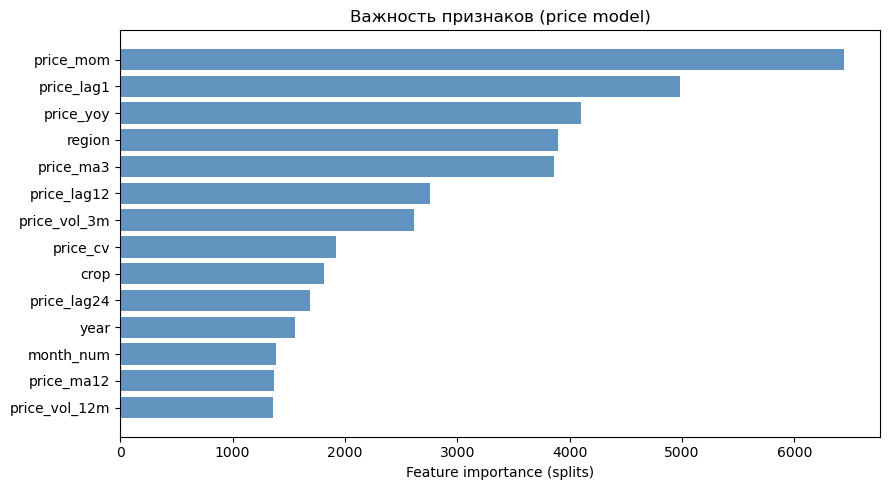

Топ-5 признаков:
   feature  importance
 price_mom        6441
price_lag1        4986
 price_yoy        4104
    region        3897
 price_ma3        3860


In [9]:
p_imp = pd.DataFrame({
    'feature':    p_all_feats,
    'importance': final_price.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(p_imp['feature'][::-1], p_imp['importance'][::-1], color='steelblue', alpha=0.85)
ax.set_title('Важность признаков (price model)')
ax.set_xlabel('Feature importance (splits)')
plt.tight_layout()
plt.show()

print('Топ-5 признаков:')
print(p_imp.head(5).to_string(index=False))

## 7. Сохранение артефактов

In [10]:
joblib.dump(final_price, MODELS_DIR / 'price_model.pkl')
joblib.dump(p_encoders,  MODELS_DIR / 'price_encoders.pkl')
p_imp.to_csv(MODELS_DIR / 'price_feature_importance.csv', index=False)

price_meta = {
    'features_numeric': p_num_cols,
    'features_cat':     PRICE_CAT,
    'features_all':     p_all_feats,
    'target':           PRICE_TARGET,
    'log_target':       False,
    'cv_r2_mean':       round(float(p_cv_df['r2'].mean()), 4),
    'cv_rmse_mean':     round(float(p_cv_df['rmse'].mean()), 2),
    'cv_mape_mean':     round(float(p_cv_df['mape'].mean()), 2),
    'trained_at':       datetime.now().isoformat(),
    'n_train':          int(len(pdf_model)),
    'years':            f"{int(pdf_model['year'].min())}-{int(pdf_model['year'].max())}",
    'crops':            sorted(pdf_model['crop'].unique().tolist()),
    'top5_features':    p_imp['feature'].head(5).tolist(),
}

with open(MODELS_DIR / 'price_meta.json', 'w', encoding='utf-8') as f:
    json.dump(price_meta, f, ensure_ascii=False, indent=2)

print('Артефакты сохранены:')
print(f'  price_model.pkl')
print(f'  price_encoders.pkl')
print(f'  price_meta.json')
print(f'  price_feature_importance.csv')
print(f'\nCV R2  = {p_cv_df["r2"].mean():.4f}')
print(f'CV RMSE= {p_cv_df["rmse"].mean():.0f} руб/т')
print(f'CV MAPE= {p_cv_df["mape"].mean():.1f}%')

Артефакты сохранены:
  price_model.pkl
  price_encoders.pkl
  price_meta.json
  price_feature_importance.csv

CV R2  = 0.9399
CV RMSE= 1568 руб/т
CV MAPE= 2.1%


## 8. Пример инференса

Важный нюанс: без исторических лагов (price_lag1, price_lag12 и т.д.) модель
выдаёт бессмысленный результат (~1758 руб). Сервис это знает и при отсутствии
данных возвращает `null` вместо ложного прогноза.

In [11]:
model_loaded    = joblib.load(MODELS_DIR / 'price_model.pkl')
encoders_loaded = joblib.load(MODELS_DIR / 'price_encoders.pkl')
with open(MODELS_DIR / 'price_meta.json', encoding='utf-8') as f:
    meta_loaded = json.load(f)

# Запрос: пшеница, Алтайский край, август 2025
# Включаем реальные лаги — без них модель работает некорректно
sample = {
    'crop':         'wheat',
    'region':       'Алтайский край',
    'year':         2025,
    'month_num':    8,
    'price_lag1':   14500.0,    # цена месяц назад
    'price_lag12':  13200.0,    # цена год назад
    'price_lag24':  12000.0,
    'price_ma3':    14200.0,
    'price_ma12':   13500.0,
    'price_mom':    2.1,
    'price_yoy':    9.8,
    'price_vol_3m': 350.0,
    'price_vol_12m': 800.0,
    'price_cv':     0.06,
}

# Кодируем категориальные
for col, le in encoders_loaded.items():
    val = str(sample.get(col, ''))
    if val not in set(le.classes_):
        val = le.classes_[0]
    sample[col] = int(le.transform([val])[0])

X_sample = pd.DataFrame([{f: sample.get(f, 0) for f in meta_loaded['features_all']}])
pred_price = float(model_loaded.predict(X_sample)[0])

print(f'Прогноз цены пшеницы (Алтайский край, авг 2025): {pred_price:,.0f} руб/т')

Прогноз цены пшеницы (Алтайский край, авг 2025): 34,622 руб/т
